In [1]:
import torch
from torchvision.datasets import CIFAR10
from torchvision import transforms, models
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from torcheval.metrics import PeakSignalNoiseRatio

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
def pgd(model, x, y, epsilon, alpha, num_iter):
    # Construct PGD adversarial examples on the examples X
    # inputs:
    #     net: the network through which we pass the inputs
    #     x: the original example which we aim to perturb to make an adversarial example
    #     y: the true label of x
    #     alpha: step size
    #     epsilon: perturbation budget
    #     iter: number of iterations in the PGD algorithm
    # test
    # outputs:
    #     x_adv : the adversarial example constructed from x
    delta = torch.zeros_like(x, requires_grad=True)
    for t in range(num_iter):
        loss = nn.CrossEntropyLoss()(model(x + delta), y)
        loss.backward()
        delta.data = (delta + x.shape[0] * alpha * delta.grad.data).clamp(-epsilon, epsilon)
        delta.grad.zero_()

    return torch.clip(delta.detach() + x, 0, 1)

def fgsm(model, x, y, epsilon):
    # Construct FGSM adversarial examples on the examples X
    #     inputs:
    #         net: the network through which we pass the inputs
    #         x: the original example which we aim to perturb to make an adversarial example
    #         y: the true label of x
    #         eps: perturbation budget
    #     outputs:
    #         x_adv : the adversarial example constructed from x

    eta = torch.zeros_like(x, requires_grad=True)
    loss = nn.CrossEntropyLoss()(model(x + eta), y)
    loss.backward()
    return torch.clip(epsilon * eta.grad.detach().sign() + x, 0, 1)

metric = PeakSignalNoiseRatio()

In [5]:
eps = 8.0/255
alpha = 5.0
its = 7

model = models.resnet50()
# modify the input and output layers
# model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.fc = nn.Linear(2048, 10)
model.load_state_dict(torch.load('model/ResNet50_CIFAR.pth'))
model = model.to(device)

In [41]:
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

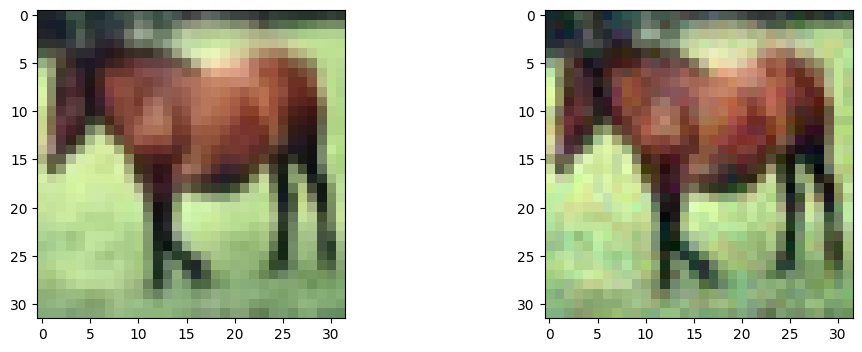

In [42]:
test = fgsm(model, x, y, eps)
# test = pgd(model, x, y, eps, alpha, its)
test = test.cpu()
x = x.cpu()
#show images
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(x[7].permute(1, 2, 0))
ax[1].imshow(test[7].permute(1, 2, 0))
plt.show()

In [43]:
metric.reset()
metric.update(test[7], x[7])
metric.compute()

tensor(29.5065)

In [221]:
#fgsm attack
atk_img = []
atk_label = []
model.eval()
val_correct = 0
# val_bar = tqdm(train_loader, position=0, leave=True)
val_bar = tqdm(test_loader, position=0, leave=True)
for x, y in val_bar:
    x, y = x.to(device), y.to(device)
    # atk_x = fgsm(model, x, y, eps)
    atk_x = pgd(model, x, y, eps, alpha, its)
    with torch.no_grad():
        y_pred = model(atk_x)
        atk_x = atk_x.permute(0, 2, 3, 1)
        atk_img += atk_x
        atk_label += y
        class_pred = y_pred.argmax(dim=1)
        val_correct += class_pred.eq(y).sum().item()
# val_accuracy = val_correct / len(train_dataset)
val_accuracy = val_correct / len(test_dataset)

print(f" attack accuracy: {val_accuracy:.4f}")

100%|██████████| 20/20 [00:16<00:00,  1.20it/s]

 attack accuracy: 0.1876


resnet_pgd_cifar_train 0.2003

resnet_fgsm_cifar_train 0.2071

resnet_fgsm_cifar_test 0.1918

resnet_pgd_cifar_test 0.1876

In [222]:
from torch.utils.data import Dataset
class AdvDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)

In [223]:
adv_dataset = AdvDataset(atk_img, atk_label)

In [224]:
torch.save(adv_dataset, './adv_data/resnet_pgd_cifar_test')